In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

# ==============================
# 2️⃣ Load data
# ==============================
df = pd.read_csv("drive/MyDrive/my_project_ml_fresh/data/San.csv")


After SMOTE, class distribution:
pass_fail
1    930
0    930
Name: count, dtype: int64
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Confusion Matrix:
 [[182   0]
 [ 11 179]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       182
           1       1.00      0.94      0.97       190

    accuracy                           0.97       372
   macro avg       0.97      0.97      0.97       372
weighted avg       0.97      0.97      0.97       372


Misclassified Students:
     student_id  pass_fail
429      S0430          1
29       S0030          1
744      S0745          1
859      S0860          1
32       S0033          1
486      S0487          1
49       S0050          1
354      S0355          1
422      S0423          1
374      S0375          1
855      S0856          1


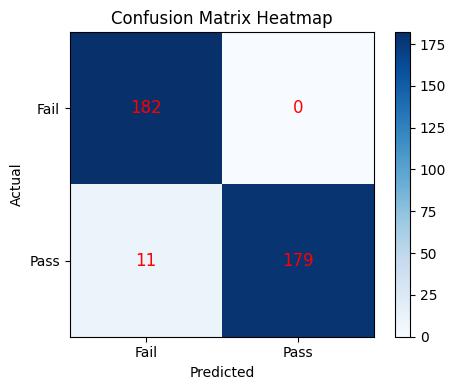

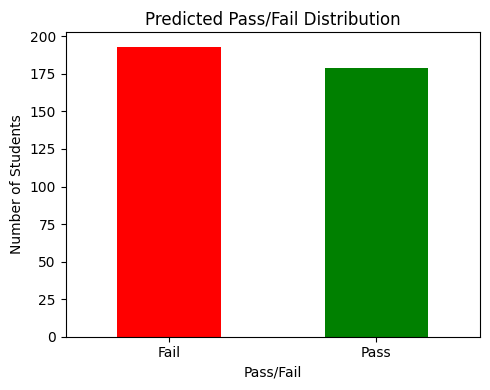

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt






df = pd.read_csv('drive/MyDrive/my_project_ml_fresh/data/san.csv')  # replace with your dataset path



X = df.drop(columns=['student_id', 'pass_fail', 'grade', 'final_score'])  # drop non-predictive columns
y = df['pass_fail']
X = pd.get_dummies(X, drop_first=True)




smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE, class distribution:")
print(pd.Series(y_res).value_counts())


X_train, X_test, y_train, y_test = train_test_split(
X_res, y_res, test_size=0.2, random_state=42
)







params = {
'n_estimators': [100, 200],
'learning_rate': [0.05, 0.1],
'max_depth': [3, 4]
}

gbc = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gbc, params, cv=5, scoring='f1')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)



y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



print("\nClassification Report:\n", classification_report(y_test, y_pred))


misclassified_idx = X_test[y_test != y_pred].index
misclassified_students = df.loc[misclassified_idx, ['student_id', 'pass_fail']]
print("\nMisclassified Students:\n", misclassified_students)







plt.figure(figsize=(5,4))   # 👈 size control

plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix Heatmap')
plt.colorbar()
plt.xticks([0,1], ['Fail','Pass'])
plt.yticks([0,1], ['Fail','Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red', fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix.png")   # 👈 ADD THIS
plt.show()


plt.figure(figsize=(5,4))

pred_counts = pd.Series(y_pred).value_counts()
pred_counts.plot(kind='bar', color=['red','green'])

plt.title('Predicted Pass/Fail Distribution')
plt.xlabel('Pass/Fail')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0,1], labels=['Fail','Pass'], rotation=0)

plt.tight_layout()
plt.savefig("prediction_distribution.png")   # 👈 ADD THIS
plt.show()
